# RPS Territorial Walkers — Circular Territories

This notebook keeps the same walker mechanics and changes only the territory/spawn geometry to circular rings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

EMPTY, ROCK, PAPER, SCISSORS = 0, 1, 2, 3
BASE_UPSET_CAPTURE_PROB = 0.025

STATE_COLORS = {
    EMPTY: "#f0f0f0",
    ROCK: "#000000",
    PAPER: "#0095DA",
    SCISSORS: "#86ff23"
}
STATE_NAMES = {
    EMPTY: "Empty",
    ROCK: "Rock",
    PAPER: "Paper",
    SCISSORS: "Scissors"
}

cmap = ListedColormap([STATE_COLORS[s] for s in [EMPTY, ROCK, PAPER, SCISSORS]])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

In [2]:
def winner(a, b):
    if a == b:
        return a
    if {a, b} == {ROCK, SCISSORS}:
        return ROCK
    if {a, b} == {SCISSORS, PAPER}:
        return SCISSORS
    if {a, b} == {PAPER, ROCK}:
        return PAPER
    raise ValueError(f"Invalid species pair: {a}, {b}")

def local_species_counts(walkers, n, m):
    counts = np.zeros((n, m, 4), dtype=np.int32)
    for w in walkers:
        counts[w["x"], w["y"], w["species"]] += 1
    return counts

def against_flow_capture_probability(attacker_count, defender_count, base_prob=BASE_UPSET_CAPTURE_PROB):
    advantage = max(0, int(attacker_count) - int(defender_count))
    return min(1.0, base_prob * advantage)

def step_system(grid, walkers, rng, periodic=False, flow_win_prob=1.0):
    n, m = grid.shape
    cell_counts = local_species_counts(walkers, n, m)
    moves = np.array([(-1, 0), (1, 0), (0, -1), (0, 1)], dtype=np.int8)

    for i in rng.permutation(len(walkers)):
        w = walkers[i]
        x_old, y_old = w["x"], w["y"]
        species = int(w["species"])

        dx, dy = moves[rng.integers(0, 4)]
        x_new, y_new = x_old + int(dx), y_old + int(dy)

        if periodic:
            x_new %= n
            y_new %= m
        else:
            if not (0 <= x_new < n and 0 <= y_new < m):
                continue

        cell_counts[x_old, y_old, species] = max(0, cell_counts[x_old, y_old, species] - 1)

        destination = int(grid[x_new, y_new])
        final_species = species

        if destination == EMPTY:
            grid[x_new, y_new] = species
        elif destination != species:
            normal_winner = winner(species, destination)
            attacker_count = int(cell_counts[x_new, y_new, species]) + 1
            defender_count = int(cell_counts[x_new, y_new, destination])

            if normal_winner == species:
                conflict_winner = species if rng.random() < flow_win_prob else destination
            else:
                p_upset = against_flow_capture_probability(attacker_count, defender_count)
                conflict_winner = species if rng.random() < p_upset else destination

            grid[x_old, y_old] = conflict_winner
            grid[x_new, y_new] = conflict_winner
            final_species = int(conflict_winner)

        w["x"], w["y"], w["species"] = x_new, y_new, int(final_species)
        cell_counts[x_new, y_new, int(final_species)] += 1

def detect_borders(grid, periodic=False):
    n, m = grid.shape
    border_mask = np.zeros((n, m), dtype=bool)
    for x in range(n):
        for y in range(m):
            s = grid[x, y]
            for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                xn, yn = x + dx, y + dy
                if periodic:
                    xn %= n
                    yn %= m
                elif not (0 <= xn < n and 0 <= yn < m):
                    continue
                if grid[xn, yn] != s:
                    border_mask[x, y] = True
                    break
    return border_mask

def detect_takeover(grid):
    u = np.unique(grid)
    if len(u) == 1 and u[0] in (ROCK, PAPER, SCISSORS):
        return True, int(u[0])
    return False, None

def draw_color_key(ax_key):
    ax_key.axis("off")
    ax_key.set_title("Color key", fontsize=11)
    key_states = [ROCK, PAPER, SCISSORS, EMPTY]
    y0, dy = 0.82, 0.18
    for i, s in enumerate(key_states):
        y = y0 - i * dy
        ax_key.add_patch(
            plt.Rectangle(
                (0.08, y - 0.045),
                0.22,
                0.09,
                facecolor=STATE_COLORS[s],
                edgecolor="black",
                transform=ax_key.transAxes,
                clip_on=False,
            )
        )
        ax_key.text(
            0.36,
            y,
            f"{STATE_NAMES[s]} ({s})",
            transform=ax_key.transAxes,
            va="center",
            fontsize=10,
        )

def show_grid(grid, title="Grid"):
    fig, (ax, ax_key) = plt.subplots(
        1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [1.0, 0.42]}
    )
    ax.imshow(grid, cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    draw_color_key(ax_key)
    fig.tight_layout()
    plt.show()

In [7]:
# Scenario-specific setup: 120°-120°-120° Y-symmetry territories

def setup_circular_territories(n=120, border_spawn_prob=0.35, seed=0, periodic=False):
    """
    Build three equal angular sectors (Y symmetry) that meet at the center.
    Each sector is 120 degrees and assigned one species.
    Walkers spawn on inter-zone borders.
    """
    rng = np.random.default_rng(seed)
    grid = np.zeros((n, n), dtype=np.int8)

    cx = (n - 1) / 2.0
    cy = (n - 1) / 2.0

    # Three unit vectors separated by 120°
    d_rock = np.array([0.0, 1.0])                   # up
    d_scissors = np.array([np.sqrt(3) / 2.0, -0.5]) # down-right
    d_paper = np.array([-np.sqrt(3) / 2.0, -0.5])   # down-left

    dirs = np.vstack([d_rock, d_paper, d_scissors])
    species_map = np.array([ROCK, PAPER, SCISSORS], dtype=np.int8)

    # Assign each cell to the sector with the largest dot product
    for x in range(n):
        for y in range(n):
            vx = (y + 0.5) - cy  # horizontal component
            vy = (x + 0.5) - cx  # vertical component
            v = np.array([vx, vy])
            idx = int(np.argmax(dirs @ v))
            grid[x, y] = int(species_map[idx])

    border_mask = detect_borders(grid, periodic=periodic)

    walkers = []
    for x in range(n):
        for y in range(n):
            if border_mask[x, y] and rng.random() < border_spawn_prob:
                walkers.append({"x": x, "y": y, "species": int(grid[x, y])})

    # Ensure all species are represented by at least one walker
    for sp in [ROCK, PAPER, SCISSORS]:
        if not any(w["species"] == sp for w in walkers):
            candidates = np.argwhere((grid == sp) & border_mask)
            if len(candidates) > 0:
                idx = rng.integers(0, len(candidates))
                x0, y0 = candidates[idx]
                walkers.append({"x": int(x0), "y": int(y0), "species": int(sp)})

    return grid, walkers, rng


def run_circular_trial(n=120, steps=1600, seed=7, periodic=False, frame_skip=25, border_spawn_prob=0.35):
    grid, walkers, rng = setup_circular_territories(
        n=n, border_spawn_prob=border_spawn_prob, seed=seed, periodic=periodic
    )
    frames = [grid.copy()]
    frame_steps = [0]
    takeover_step, winner_species = None, None

    for t in range(1, steps + 1):
        step_system(grid, walkers, rng, periodic=periodic, flow_win_prob=0.95)
        if (t % frame_skip) == 0:
            frames.append(grid.copy())
            frame_steps.append(t)
        done, ws = detect_takeover(grid)
        if done:
            takeover_step, winner_species = t, ws
            if (t % frame_skip) != 0:
                frames.append(grid.copy())
                frame_steps.append(t)
            break

    return {
        "grid": grid,
        "walkers": walkers,
        "frames": frames,
        "frame_steps": frame_steps,
        "takeover_step": takeover_step,
        "winner_species": winner_species
    }

### JC: I made the same mistake as the vertical symmetry cell :( but I found it nearly identical in behavior as the previous one. Larger n increases the period of stability, but also I notice that this symmetry spreads its chaos in a Y shape similar to its original symmetry. I think this could be attributed to the fact that its easier for the opposing faction to ride the line where they are dominant than not.


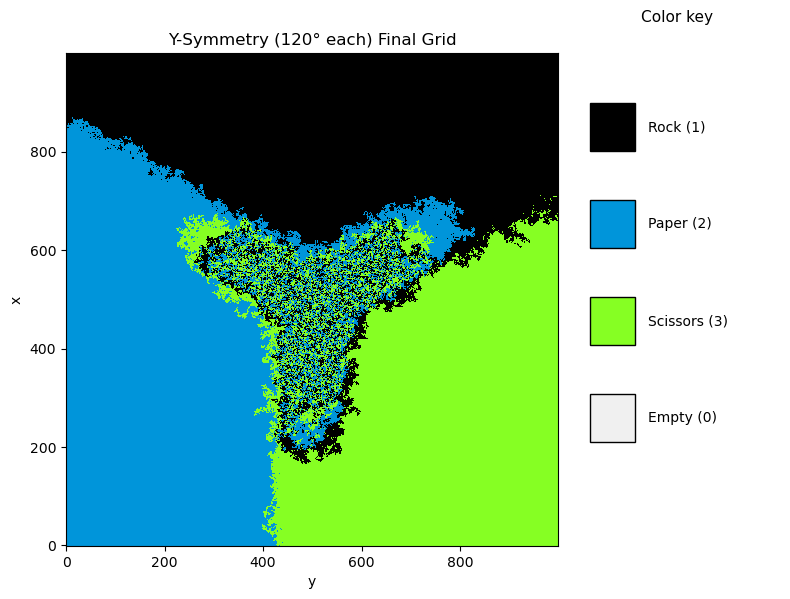

{'takeover_step': None, 'winner': None, 'num_walkers': 2968, 'num_saved_frames': 41}


In [18]:
result = run_circular_trial(n=1000, steps=4000, seed=132, periodic=False, frame_skip=100, border_spawn_prob=0.99)
show_grid(result["grid"], title="Y-Symmetry (120° each) Final Grid")
print({
    "takeover_step": result["takeover_step"],
    "winner": None if result["winner_species"] is None else STATE_NAMES[result["winner_species"]],
    "num_walkers": len(result["walkers"]),
    "num_saved_frames": len(result["frames"])
})

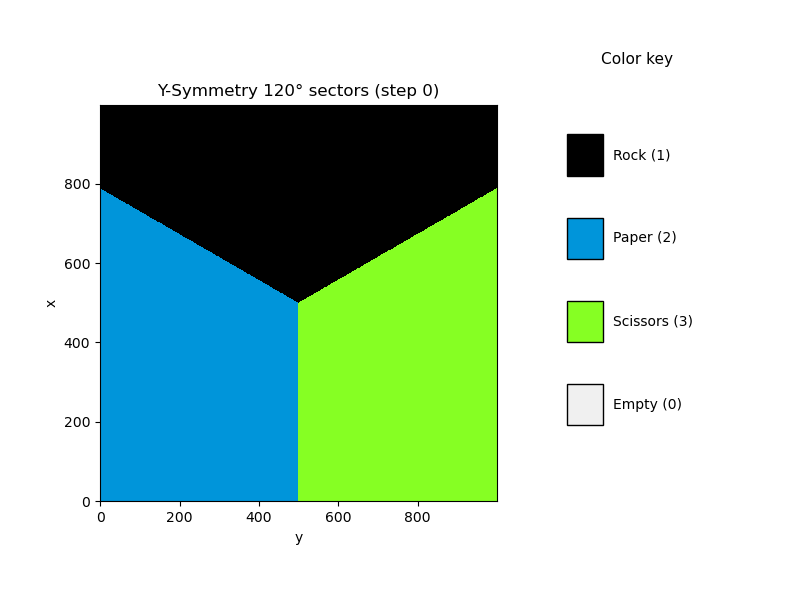

Saved GIF: /Users/joshuaclavecillas/anaconda_projects/Computational_folder/circular_territories.gif
Rendered embedded HTML animation.


In [19]:
from pathlib import Path
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML, Image, display


def render_frames_gif_and_html(frames, frame_steps=None, gif_name="circular_territories.gif", fps=12):
    if not frames:
        raise ValueError("No frames available to animate.")

    if frame_steps is None:
        frame_steps = list(range(len(frames)))
    if len(frame_steps) != len(frames):
        raise ValueError("frame_steps must have same length as frames.")

    gif_path = Path.cwd() / gif_name

    fig, (ax, ax_key) = plt.subplots(
        1, 2, figsize=(8, 6), gridspec_kw={"width_ratios": [1.0, 0.42]}
    )
    im = ax.imshow(frames[0], cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
    ax.set_xlabel("y")
    ax.set_ylabel("x")
    draw_color_key(ax_key)

    def update(i):
        im.set_data(frames[i])
        ax.set_title(f"Y-Symmetry 120° sectors (step {frame_steps[i]})")
        return [im]

    ani = FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps, blit=False)

    ani.save(gif_path, writer=PillowWriter(fps=fps))
    html_anim = ani.to_jshtml(fps=fps)
    plt.close(fig)

    display(HTML(html_anim))
    display(Image(filename=str(gif_path)))

    print(f"Saved GIF: {gif_path}")
    print("Rendered embedded HTML animation.")


render_frames_gif_and_html(
    result["frames"],
    frame_steps=result["frame_steps"],
    gif_name="circular_territories.gif",
    fps=12
    )

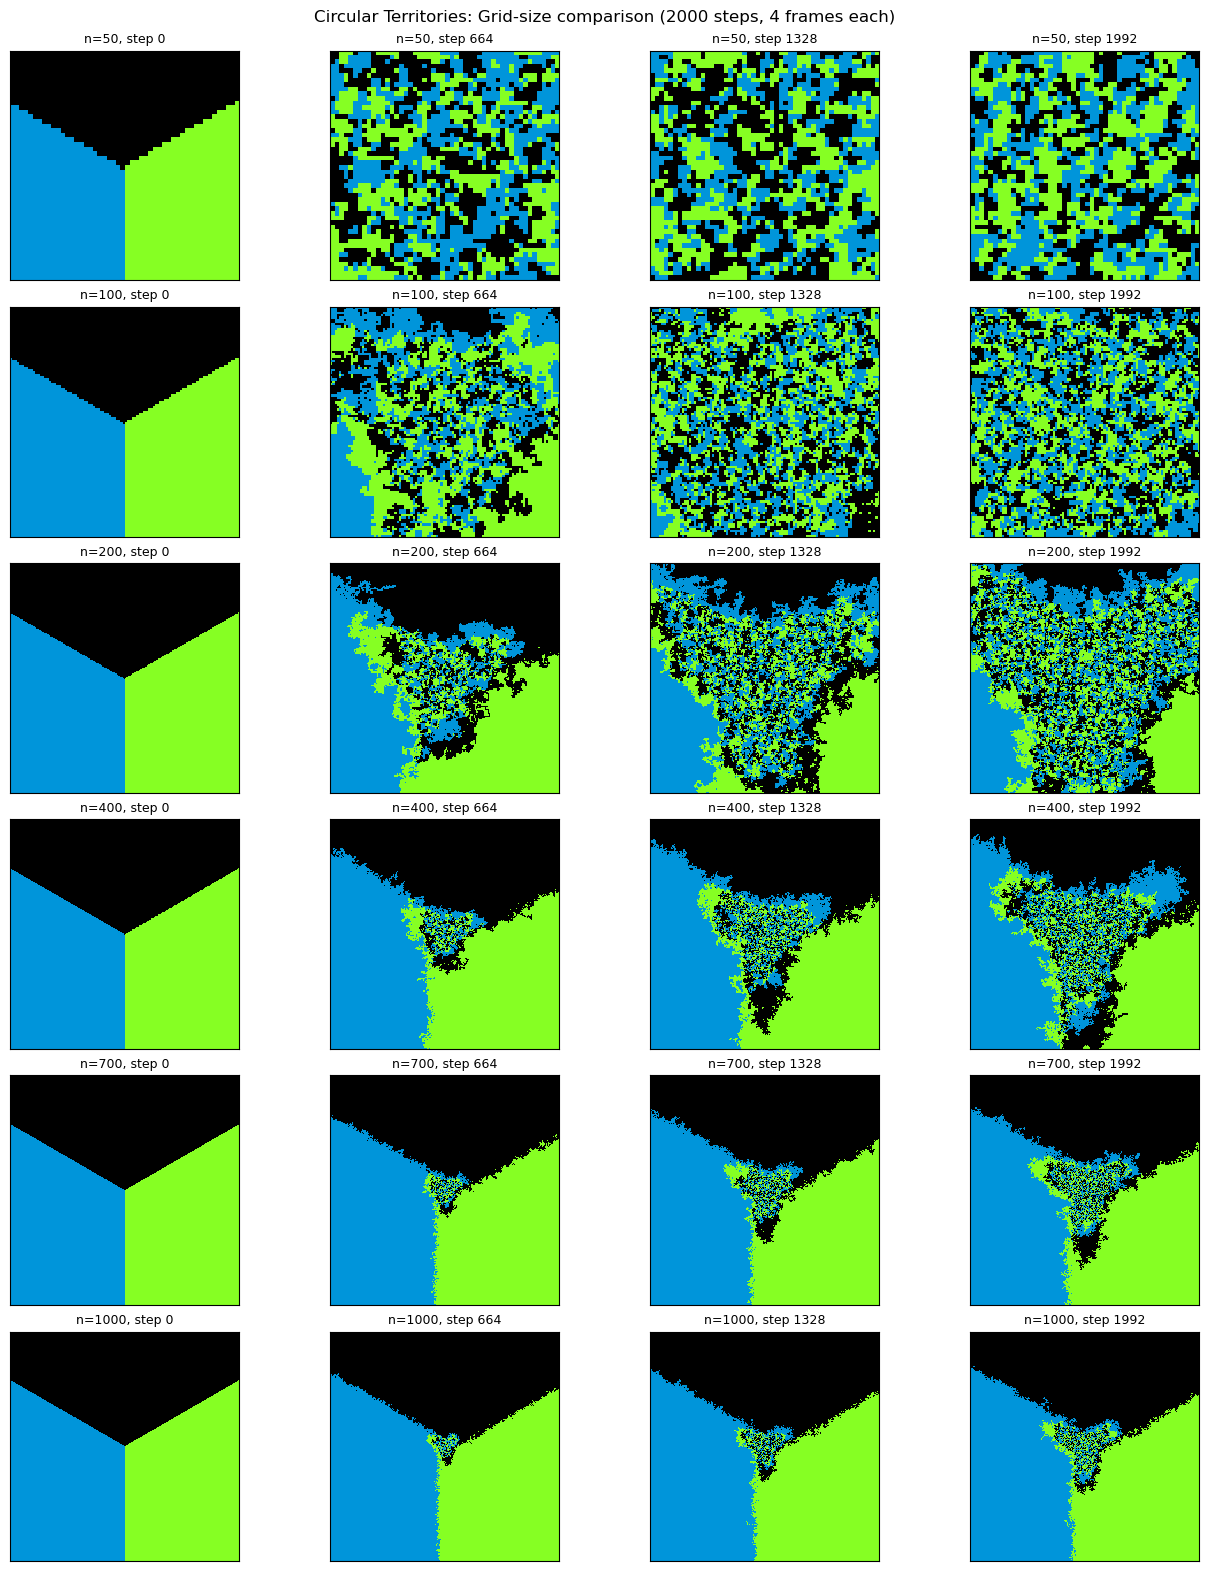

Saved comparison PNG: /Users/joshuaclavecillas/anaconda_projects/Computational_folder/circular_grid_size_comparison.png


In [17]:
from pathlib import Path

# Compare different grid sizes on one PNG (2000 steps each, 4 frames each).
grid_sizes = [50, 100, 200, 400, 700, 1000]
steps = 2000
frames_per_trial = 4
seed_base = 100

def nearest_frame_indices(frame_steps, targets):
    frame_steps_arr = np.asarray(frame_steps)
    idx = []
    for t in targets:
        idx.append(int(np.argmin(np.abs(frame_steps_arr - t))))
    return idx

target_steps = np.linspace(0, steps, frames_per_trial, dtype=int)

fig, axes = plt.subplots(
    len(grid_sizes),
    frames_per_trial,
    figsize=(3.2 * frames_per_trial, 2.6 * len(grid_sizes)),
    constrained_layout=True,
    squeeze=False,
 )

for row, n in enumerate(grid_sizes):
    # Save enough frames so we can choose 4 representative time points.
    trial = run_circular_trial(
        n=n,
        steps=steps,
        seed=seed_base + row,
        periodic=False,
        frame_skip=max(1, steps // 24),
        border_spawn_prob=0.99,
    )

    frames = trial["frames"]
    frame_steps = trial["frame_steps"]
    chosen_idx = nearest_frame_indices(frame_steps, target_steps)

    for col, idx in enumerate(chosen_idx):
        ax = axes[row, col]
        ax.imshow(frames[idx], cmap=cmap, norm=norm, origin="lower", interpolation="nearest")
        ax.set_title(f"n={n}, step {frame_steps[idx]}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

png_path = Path.cwd() / "circular_grid_size_comparison.png"
fig.suptitle("Circular Territories: Grid-size comparison (2000 steps, 4 frames each)", fontsize=12)
fig.savefig(png_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved comparison PNG: {png_path}")